In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [15]:
df = pd.read_csv('../__datasets__/weight-height.csv')
df.sample(5)

,Gender,Height,Weight
5254,Female,64.467065,143.663382
4763,Male,65.344463,174.258683
7804,Female,66.532392,159.636138
7961,Female,67.236780,154.705742
1322,Male,67.903340,192.651605


In [16]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

## Trimming

<Axes: >

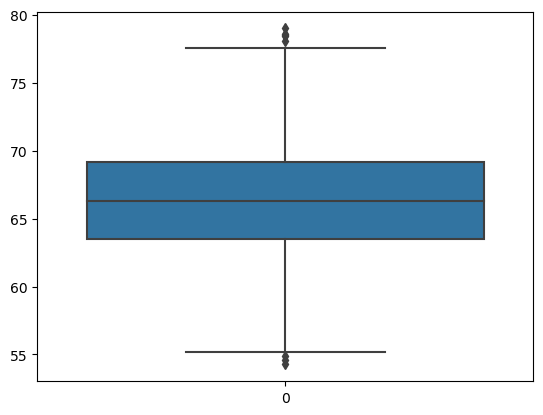

In [17]:
sns.boxplot(df['Height'])

In [18]:
upper_lim = df['Height'].quantile(0.99)
upper_lim

74.7857900583366

In [19]:
lower_lim = df['Height'].quantile(0.01)
lower_lim

58.13441158671655

In [20]:
new_df = df[(df['Height'] < upper_lim) & (df['Height'] > lower_lim)]
new_df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [21]:
new_df.describe()

,Height,Weight
count,9800.000000,9800.000000
mean,66.364366,161.399489
std,3.645075,30.933549
min,58.134496,77.523774
25%,63.577162,136.322717
50%,66.318070,161.212928
75%,69.119896,186.753317
max,74.785714,249.946283


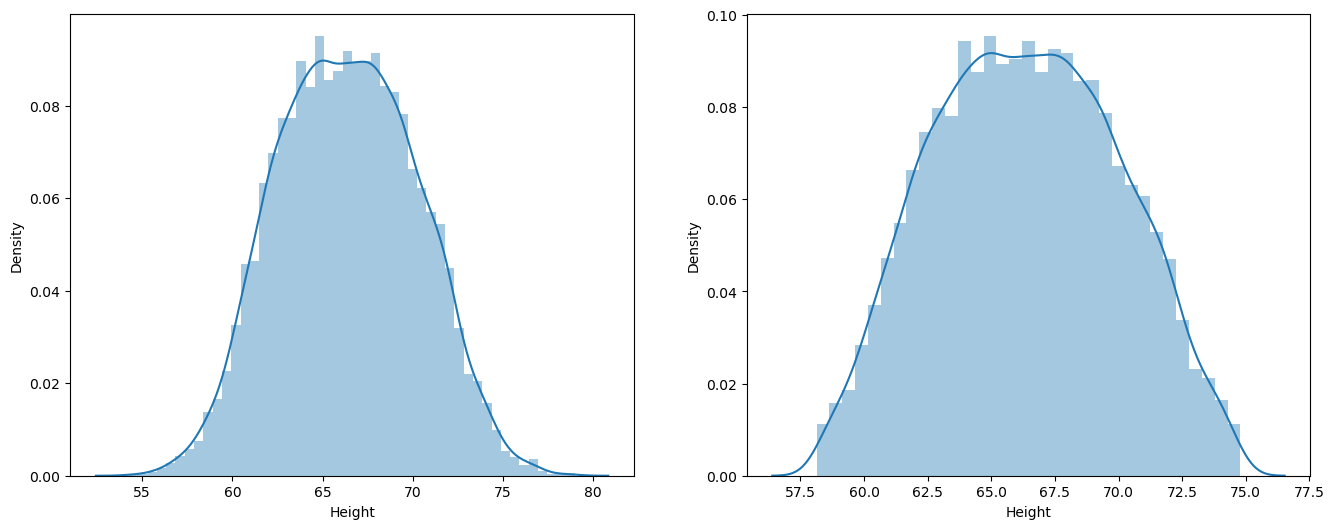

In [30]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.distplot(df['Height'])

plt.subplot(1, 2, 2)
sns.distplot(new_df['Height'])

plt.show()

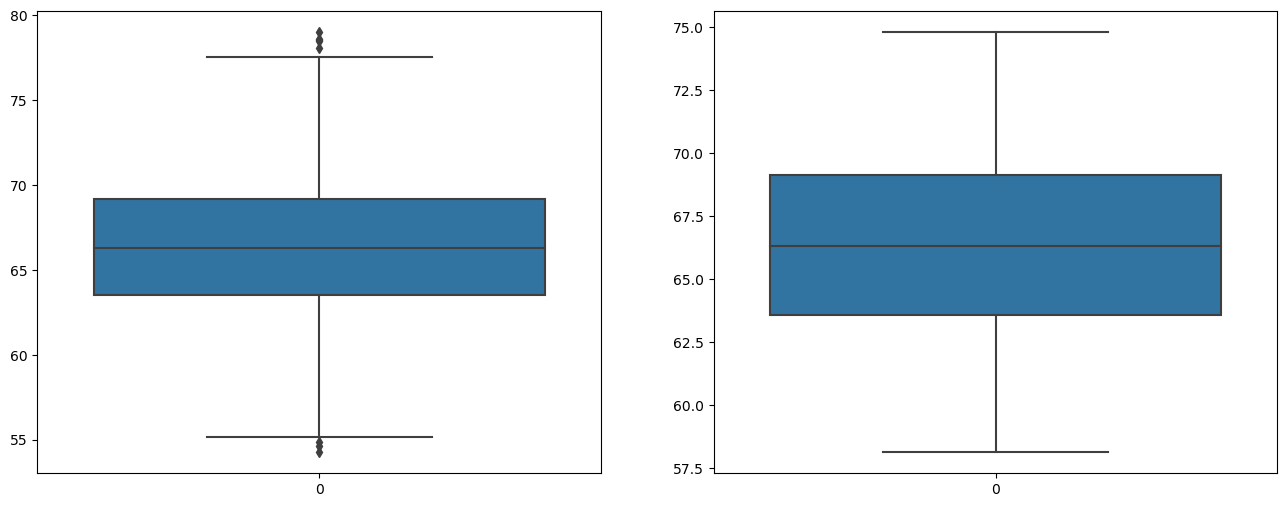

In [31]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.boxplot(df['Height'])

plt.subplot(1, 2, 2)
sns.boxplot(new_df['Height'])

plt.show()

## Capping -> Winsorization

In [43]:
new_df2['Height'] = np.where(
    df['Height'] > upper_lim,
    upper_lim,
    np.where(
        df['Height'] < lower_lim,
        lower_lim,
        df['Height']
    )
)
new_df2['Height'] = pd.DataFrame(new_df2['Height'])

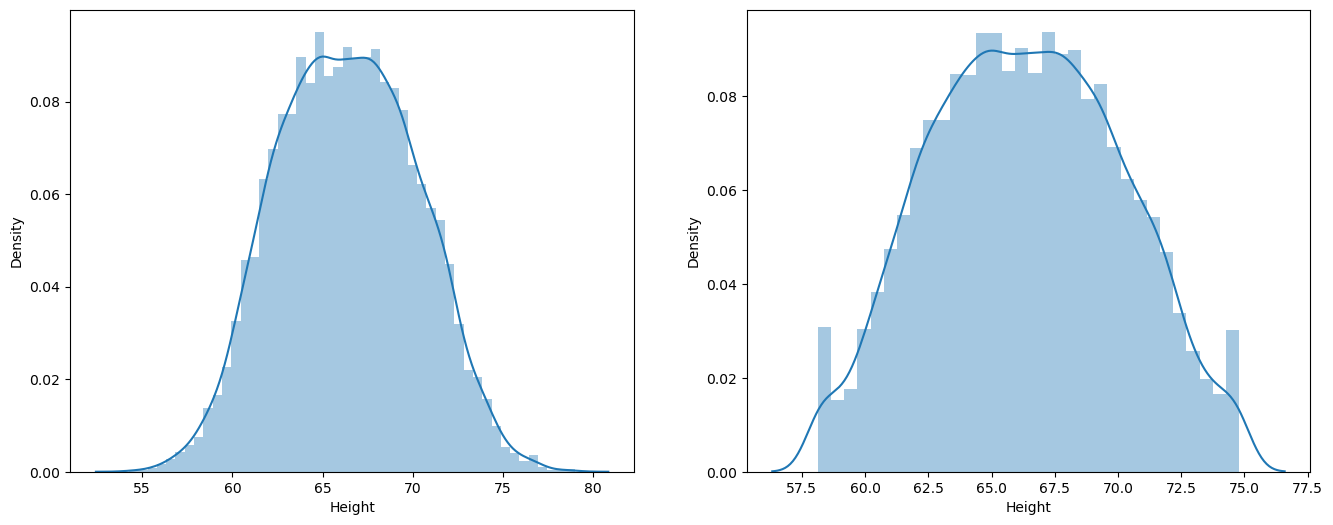

In [44]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.distplot(df['Height'])

plt.subplot(1, 2, 2)
sns.distplot(new_df2['Height'])

plt.show()

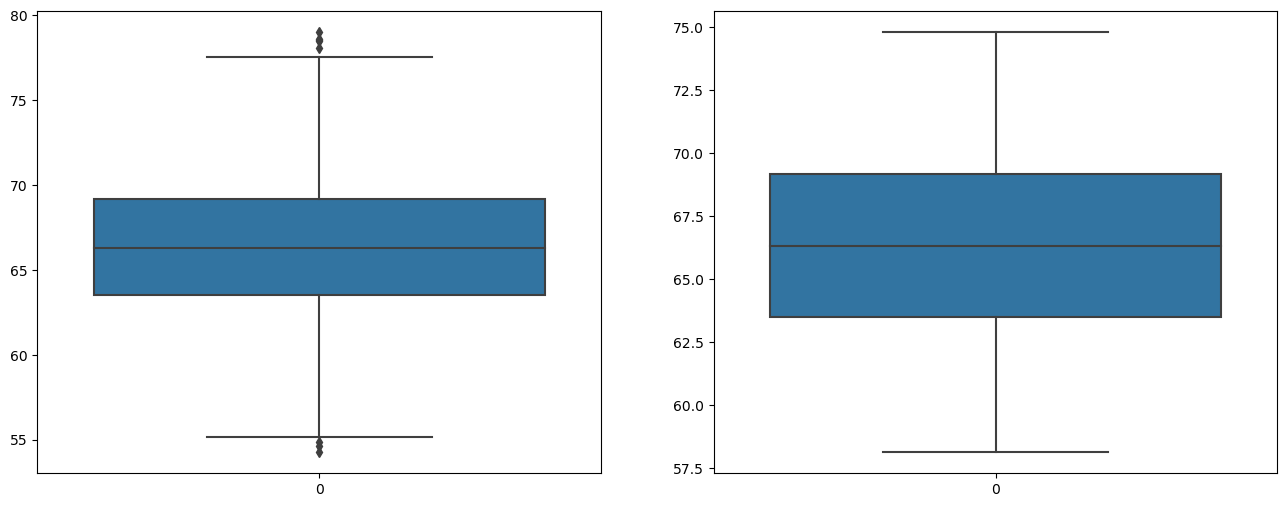

In [45]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.boxplot(df['Height'])

plt.subplot(1, 2, 2)
sns.boxplot(new_df2['Height'])

plt.show()